In [1]:
# Importing Libraries
from IPython.display import display
import itertools
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import os
import pandas as pd
from pathlib import Path
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
import random, os
import seaborn as sns
import shutil
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import sys
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow import lite
import tensorflow as tf
from tensorflow.keras.metrics import categorical_accuracy
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras import regularizers
from time import perf_counter

init_notebook_mode(connected = True)

In [2]:
# Reading Data
df = pd.read_csv(r'/content/drive/MyDrive/Small_DR/train_shiva.csv')

diagnosis_stages = {
    0 : 'No_DR',
    1 : 'Mild',
    2 : 'Moderate',
    3 : 'Severe',
    4 : 'Proliferate_DR',
}

# Assinging the Diabetic Retinopathy stages and binary type to their id code and diagnosis number
df['stages'] = df['diagnosis'].map(diagnosis_stages.get)
df.head()

,id_code,diagnosis,stages
0,000c1434d8d7,2,Moderate
1,001639a390f0,4,Proliferate_DR
2,0024cdab0c1e,1,Mild
3,002c21358ce6,0,No_DR
4,005b95c28852,0,No_DR


<Axes: >

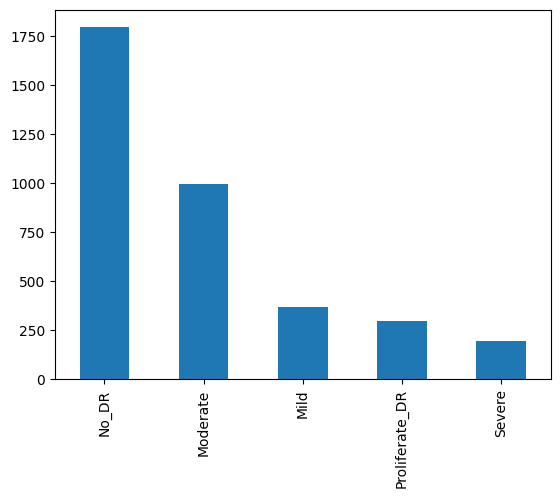

In [3]:
df['stages'].value_counts().plot(kind='bar')

In [4]:
# Split data into stratified train, validation, and test sets
train_temp, val = train_test_split(df, test_size = 0.15, stratify = df['stages'], random_state = 1)
train, test = train_test_split(train_temp, test_size = 0.15 / (1 - 0.15), stratify = train_temp['stages'], random_state = 1)

# Display the number of files for each set and their respective stage
print(train['stages'].value_counts(), '\n')
print(val['stages'].value_counts(), '\n')
print(test['stages'].value_counts(), '\n')

No_DR             1256
Moderate           696
Mild               258
Proliferate_DR     207
Severe             135
Name: stages, dtype: int64 

No_DR             270
Moderate          150
Mild               55
Proliferate_DR     44
Severe             29
Name: stages, dtype: int64 

No_DR             270
Moderate          149
Mild               56
Proliferate_DR     44
Severe             29
Name: stages, dtype: int64 



In [5]:
# Create working directories for the train, validation, and test sets
base_dir = ''

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

if os.path.exists(base_dir) :
    shutil.rmtree(base_dir)

if os.path.exists(train_dir) :
    shutil.rmtree(train_dir)
os.makedirs(train_dir)

if os.path.exists(val_dir) :
    shutil.rmtree(val_dir)
os.makedirs(val_dir)

if os.path.exists(test_dir) :
    shutil.rmtree(test_dir)
os.makedirs(test_dir)

In [6]:
# Copy images to their respective working directory
source_dir = r'/content/drive/MyDrive/Small_DR/colored_images'

for i, row in train.iterrows() :
    srcfile = os.path.join(source_dir, row['stages'], (row['id_code'] + ".png"))
    dstfile = os.path.join(train_dir, row['stages'])
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

for i, row in val.iterrows() :
    srcfile = os.path.join(source_dir, row['stages'], (row['id_code'] + ".png"))
    dstfile = os.path.join(val_dir, row['stages'])
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

for i, row in test.iterrows() :
    srcfile = os.path.join(source_dir, row['stages'], (row['id_code'] + ".png"))
    dstfile = os.path.join(test_dir, row['stages'])
    os.makedirs(dstfile, exist_ok = True)
    shutil.copy(srcfile, dstfile)

image_dir = Path('/content/drive/MyDrive/Small_DR/colored_images')
filepath = list(image_dir.glob(r'**/*.png'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepath))

In [7]:
# Setting up ImageDataGenerator for train, validation, and test sets
train_batch = ImageDataGenerator(rescale = 1. / 255).flow_from_directory('train', target_size = (224, 224), shuffle = True)
val_batch = ImageDataGenerator(rescale = 1. / 255).flow_from_directory('val', target_size = (224, 224), shuffle = True)
test_batch = ImageDataGenerator(rescale = 1. / 255).flow_from_directory('test', target_size = (224, 224), shuffle = False)

Found 2552 images belonging to 5 classes.
Found 548 images belonging to 5 classes.
Found 548 images belonging to 5 classes.


In [12]:
# Dictionary containing the Keras Models
models = {
    "DenseNet121": {"model":tf.keras.applications.DenseNet121, "perf":0},
    "DenseNet169": {"model":tf.keras.applications.DenseNet169, "perf":0},
    "MobileNetV2": {"model":tf.keras.applications.MobileNetV2, "perf":0},
     "NASNetMobile": {"model":tf.keras.applications.NASNetMobile, "perf":0},
    "ResNet101V2": {"model":tf.keras.applications.ResNet101V2, "perf":0},
    "ResNet152V2": {"model":tf.keras.applications.ResNet152V2, "perf":0},
    "ResNet50V2": {"model":tf.keras.applications.ResNet50V2, "perf":0},
}

In [13]:
# Method to load, compile, and return keras pretrained modelss
def get_model(model) :
    # Load the Model
    kwargs = {'input_shape' : (224, 224, 3),
              'include_top' : False,
              'weights' : 'imagenet',
              'pooling' : 'avg'}

    pretrained_model = model(**kwargs)
    pretrained_model.trainable = False

    inputs = pretrained_model.input

    x = tf.keras.layers.Dense(128, activation = 'relu')(pretrained_model.output)
    x = tf.keras.layers.Dense(128, activation = 'relu')(x)

    outputs = tf.keras.layers.Dense(5, activation = 'softmax')(x)
    model = tf.keras.Model(inputs = inputs, outputs = outputs)

    # Compile the Model
    model.compile(
        optimizer = 'adam',
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )

    # Return the Model
    return model

In [ ]:
for name, model in models.items():

    # Get the model
    m = get_model(model['model'])
    models[name]['model'] = m

    start = perf_counter()

    # Fit the model
    history = m.fit(train_batch, validation_data = val_batch, epochs = 25, verbose = 1)

    # Save the duration, train accuracy, and validation accuracy
    duration = perf_counter() - start
    duration = round(duration, 2)
    models[name]['perf'] = duration
    print(f"{name:10} trained in {duration} sec")

    val_acc = history.history['val_accuracy']
    models[name]['val_acc'] = [round(v, 4) for v in val_acc]

    train_acc = history.history['accuracy']
    models[name]['train_accuracy'] = [round(v, 4) for v in train_acc]

Epoch 1/25
80/80 [==============================] - 20s 168ms/step - loss: 0.8351 - accuracy: 0.6885 - val_loss: 0.7168 - val_accuracy: 0.7391
Epoch 2/25
80/80 [==============================] - 10s 130ms/step - loss: 0.6575 - accuracy: 0.7524 - val_loss: 0.6905 - val_accuracy: 0.7391
Epoch 3/25
80/80 [==============================] - 11s 136ms/step - loss: 0.5916 - accuracy: 0.7774 - val_loss: 0.6317 - val_accuracy: 0.7263
Epoch 4/25
80/80 [==============================] - 11s 138ms/step - loss: 0.5723 - accuracy: 0.7931 - val_loss: 0.6242 - val_accuracy: 0.7500
Epoch 5/25
80/80 [==============================] - 10s 130ms/step - loss: 0.5444 - accuracy: 0.7990 - val_loss: 0.5763 - val_accuracy: 0.7865
Epoch 6/25
80/80 [==============================] - 10s 129ms/step - loss: 0.4972 - accuracy: 0.8119 - val_loss: 0.5997 - val_accuracy: 0.7901
Epoch 7/25
80/80 [==============================] - 10s 123ms/step - loss: 0.5061 - accuracy: 0.8139 - val_loss: 0.5680 - val_accuracy: 0.7901

In [ ]:
# Create Dataframe with the results
models_result = []

for name, v in models.items():
    models_result.append([name,
                          models[name]['train_accuracy'][-1],
                          models[name]['val_acc'][-1],
                          models[name]['perf']])

df_results = pd.DataFrame(models_result,
                          columns = ['Model', 'Train Accuracy', 'Validation Accuracy', 'Training Time (sec)'])
df_results.sort_values(by = 'Validation Accuracy', ascending = False, inplace = True)
df_results.reset_index(inplace = True, drop = True)
df_results.head(28)